### NOTICE
#### Below code is just for ensuring the versions used by the SpaceDebrisRadar virtual enviornment.

In [1]:
import sys
import importlib

libs = ["pandas", "streamlit", "matplotlib", "seaborn", "sklearn", 'numpy', 'sklearn', 'scipy']

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print("-" * 70)

for lib in libs:
    try:
        module = importlib.import_module(lib)
        print(f"{lib} version: {module.__version__}")
        print(f"{lib} path: {module.__file__}")
    except ModuleNotFoundError:
        print(f"{lib} is NOT installed in this environment.")
    print("-" * 70)


Python executable: C:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\python.exe
Python version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
----------------------------------------------------------------------
pandas version: 2.3.1
pandas path: C:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\pandas\__init__.py
----------------------------------------------------------------------
streamlit version: 1.48.0
streamlit path: C:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\streamlit\__init__.py
----------------------------------------------------------------------
matplotlib version: 3.10.0
matplotlib path: C:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\matplotlib\__init__.py
----------------------------------------------------------------------
seaborn version: 0.13.2
seaborn path: C:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\seaborn\__init__.py
---------------------------

In [2]:
# IMPORT HERE!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Important thorughout this project
%matplotlib inline


In [3]:
#df = pd.read_csv('https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=csv', low_memory=False)
df = pd.read_csv('../data/01_raw/gp.csv')

### 📑 Useful Columns for SpaceDebrisRadar.AI

| Column Name     | Description                           | Usage in Project (ML/Logic) |
|-----------------|---------------------------------------|------------------------------|
| NORAD_CAT_ID    | Unique satellite identifier           | Tracking & referencing       |
| OBJECT_NAME     | Satellite/system name                 | System-based queries (e.g., Starlink) |
| MEAN_MOTION     | Revolutions per day (orbit speed)     | Clustering (KMeans), anomaly trends |
| INCLINATION     | Orbital tilt in degrees               | Clustering (shell grouping)  |
| ECCENTRICITY    | Orbit shape (circular vs. elliptical) | Orbit stability, anomaly detection |
| BSTAR           | Drag coefficient proxy                | Anomaly detection (decay risk) |
| EPOCH           | Timestamp of orbital elements         | Time-series, forecasting     |

----
### 🔎 About OBJECT_ID (A, B, C parts)

- `OBJECT_ID` format → `YYYY-NNNP`  
  - `YYYY` → Launch year  
  - `NNN` → Launch number in that year  
  - `P` → Piece (A, B, C, …)

- `A` → Primary payload (main satellite)  
- `B, C, …` → Secondary payloads, rocket bodies, or debris  
- Each part is a **separate object** in orbit (they do not join back).  
- Useful for anomaly detection → older `B/C` objects are often unstable or decaying.


In [4]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2025-10-05T10:37:28.191360,13.762289,0.002461,90.2163,65.8752,347.2003,74.9038,0,U,900,999,3638,0.001091,1.074000e-05,0.0
1,CALSPHERE 2,1964-063E,2025-10-05T11:04:00.444864,13.528741,0.001678,90.2292,69.7816,244.2673,178.7129,0,U,902,999,82182,0.000110,8.200000e-07,0.0
2,LCS 1,1965-034C,2025-10-05T12:08:01.406976,9.893092,0.001358,32.1425,61.7207,300.3713,59.5442,0,U,1361,999,18466,-0.001468,-3.000000e-08,0.0
3,TEMPSAT 1,1965-065E,2025-10-05T06:44:31.462944,13.335738,0.006776,89.9871,212.7305,243.9611,271.6250,0,U,1512,999,92607,0.000109,6.300000e-07,0.0
4,CALSPHERE 4A,1965-065H,2025-10-05T13:13:59.657952,13.362208,0.007127,89.9109,124.8412,101.8063,291.1203,0,U,1520,999,92870,0.000297,1.650000e-06,0.0


In [5]:
df.shape

(12796, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12796 entries, 0 to 12795
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OBJECT_NAME          12796 non-null  object 
 1   OBJECT_ID            12796 non-null  object 
 2   EPOCH                12796 non-null  object 
 3   MEAN_MOTION          12796 non-null  float64
 4   ECCENTRICITY         12796 non-null  float64
 5   INCLINATION          12796 non-null  float64
 6   RA_OF_ASC_NODE       12796 non-null  float64
 7   ARG_OF_PERICENTER    12796 non-null  float64
 8   MEAN_ANOMALY         12796 non-null  float64
 9   EPHEMERIS_TYPE       12796 non-null  int64  
 10  CLASSIFICATION_TYPE  12796 non-null  object 
 11  NORAD_CAT_ID         12796 non-null  int64  
 12  ELEMENT_SET_NO       12796 non-null  int64  
 13  REV_AT_EPOCH         12796 non-null  int64  
 14  BSTAR                12796 non-null  float64
 15  MEAN_MOTION_DOT      12796 non-null 

In [7]:
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
count,12796.000000,12796.000000,12796.000000,12796.000000,12796.000000,12796.000000,12796.0,12796.000000,12796.0,12796.000000,12796.000000,1.279600e+04,12796.000000
mean,14.150044,0.002830,59.700568,187.044575,163.882493,193.576440,0.0,55411.817756,999.0,13178.521335,0.000009,1.547001e-04,0.000016
std,3.364218,0.039892,24.217674,109.837579,94.073595,95.223249,0.0,8346.154768,0.0,13114.547146,0.006457,2.817796e-03,0.001069
min,0.284456,0.000004,0.001900,0.029900,0.011100,0.059300,0.0,900.000000,999.0,11.000000,-0.164540,-2.364716e-02,-0.000014
25%,14.983401,0.000124,43.004000,87.055075,87.739175,91.807675,0.0,51148.750000,999.0,4050.000000,0.000015,3.600000e-07,0.000000
50%,15.088377,0.000157,53.159500,183.251950,112.157950,243.707400,0.0,57367.500000,999.0,10461.000000,0.000154,1.597500e-05,0.000000
75%,15.301663,0.000305,86.393525,291.182475,267.562925,272.021850,0.0,62067.250000,999.0,17790.000000,0.000705,1.549425e-04,0.000000
max,16.452703,0.912262,146.927000,359.969200,359.990100,359.844100,0.0,65852.000000,999.0,99170.000000,0.083243,1.283988e-01,0.103040


In [8]:
df['OBJECT_NAME']

0                CALSPHERE 1
1                CALSPHERE 2
2                      LCS 1
3                  TEMPSAT 1
4               CALSPHERE 4A
                ...         
12791    HULIANWANG DIGUI-84
12792    HULIANWANG DIGUI-85
12793    HULIANWANG DIGUI-86
12794           SHIYAN-30 01
12795           SHIYAN-30 02
Name: OBJECT_NAME, Length: 12796, dtype: object

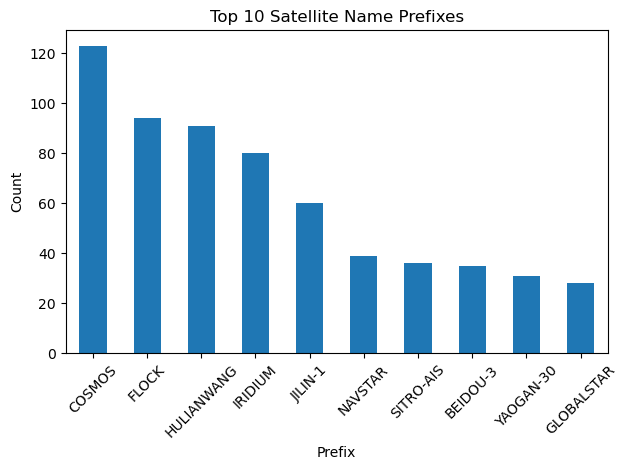

In [9]:
df['OBJECT_NAME'].str.split().str[0].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Satellite Name Prefixes')
plt.xlabel('Prefix')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()



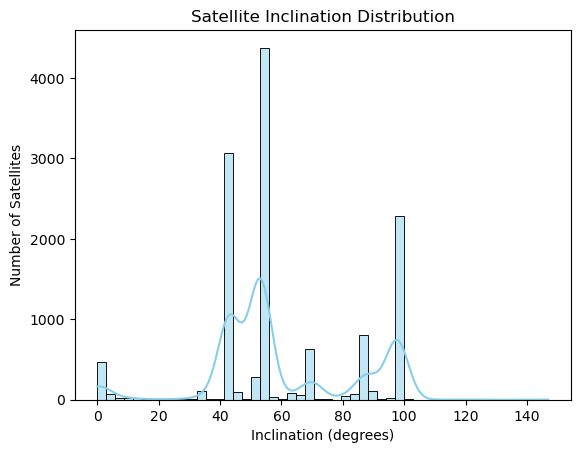

In [10]:
sns.histplot(data=df, x = 'INCLINATION', bins=50, color='skyblue', kde = True)

plt.title('Satellite Inclination Distribution')
plt.xlabel('Inclination (degrees)')
plt.ylabel('Number of Satellites')
plt.show()


(0.0, 0.05)

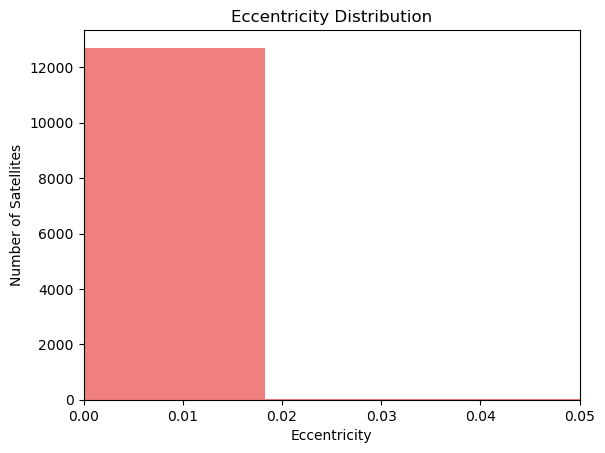

In [11]:
df['ECCENTRICITY'].plot(kind='hist', bins=50, color='lightcoral')
plt.title('Eccentricity Distribution')
plt.xlabel('Eccentricity')
plt.ylabel('Number of Satellites')

plt.xlim(0, 0.05)

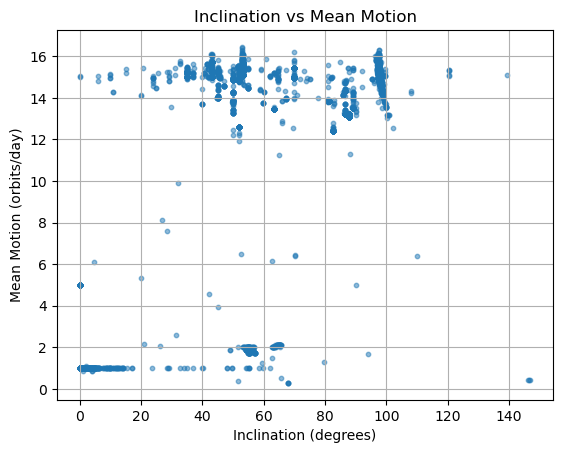

In [12]:
plt.scatter(df['INCLINATION'], df['MEAN_MOTION'], alpha=0.5, s=10)
plt.title('Inclination vs Mean Motion')
plt.xlabel('Inclination (degrees)')
plt.ylabel('Mean Motion (orbits/day)')
plt.grid(True)
plt.show()


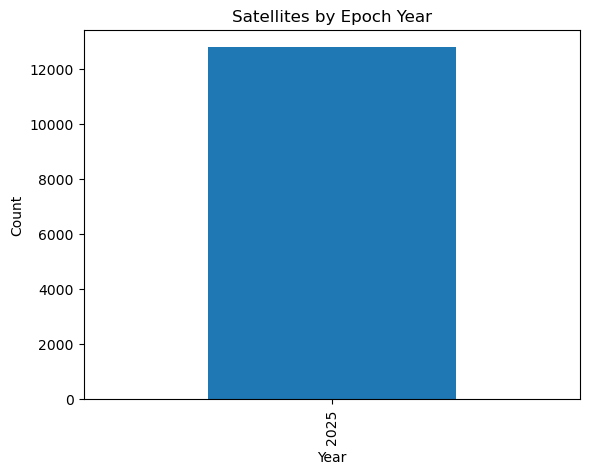

In [13]:
df['EPOCH'] = pd.to_datetime(df['EPOCH'], errors='coerce')
df['EPOCH'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title('Satellites by Epoch Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


In [14]:
df.tail()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
12791,HULIANWANG DIGUI-84,2025-220C,2025-10-03 15:24:54.820224,13.690044,0.000828,86.4926,131.1986,194.1426,165.9503,0,U,65819,999,84,0.000057,6.600000e-07,0.0
12792,HULIANWANG DIGUI-85,2025-220D,2025-10-03 15:23:56.942592,13.691724,0.000782,86.4982,131.2085,185.9250,174.1819,0,U,65820,999,84,0.000057,6.600000e-07,0.0
12793,HULIANWANG DIGUI-86,2025-220E,2025-10-04 22:57:49.099392,13.692081,0.000762,86.4964,130.7257,181.6880,178.4255,0,U,65821,999,102,0.000057,6.600000e-07,0.0
12794,SHIYAN-30 01,2025-222A,2025-10-05 12:35:11.259168,14.928145,0.000503,34.9899,350.2538,13.0573,347.0262,0,U,65851,999,96,0.000452,4.738000e-05,0.0
12795,SHIYAN-30 02,2025-222B,2025-10-05 12:34:10.183008,14.928032,0.000633,34.9984,350.2464,19.0025,341.0916,0,U,65852,999,94,0.000249,2.596000e-05,0.0


In [15]:
df[df['OBJECT_NAME'].str.contains('STARLINK')]

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
1370,STARLINK-1008,2019-074B,2025-10-05 09:17:04.269408,15.063955,0.000142,53.0541,163.8022,90.2209,269.8943,0,U,44714,999,32534,0.000749,0.000109,0.0
1371,STARLINK-1010,2019-074D,2025-10-05 00:00:02.000160,15.838035,0.000514,53.0469,107.0239,100.3795,12.1968,0,U,44716,999,601,0.001282,0.002999,0.0
1372,STARLINK-1011,2019-074E,2025-10-05 02:31:19.634304,15.736689,0.000666,53.0492,161.3600,115.2169,244.9541,0,U,44717,999,32535,0.001278,0.001868,0.0
1373,STARLINK-1012,2019-074F,2025-10-05 02:23:03.725088,15.063961,0.000191,53.0535,165.0934,84.5269,275.5938,0,U,44718,999,32529,0.000119,0.000015,0.0
1374,STARLINK-1017,2019-074L,2025-10-05 01:37:27.397344,15.124316,0.000459,53.0514,163.1644,90.8759,269.2758,0,U,44723,999,32532,0.002444,0.000429,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12766,STARLINK-35194,2025-211V,2025-10-05 12:00:00.998784,15.571438,0.000160,97.6026,319.9316,75.2764,0.1493,0,U,65671,999,357,-0.034025,-0.021855,0.0
12767,STARLINK-35198,2025-211W,2025-10-05 12:00:00.998784,15.571378,0.000161,97.6024,319.9305,67.7060,5.8051,0,U,65672,999,357,-0.033904,-0.021782,0.0
12768,STARLINK-35177,2025-211X,2025-10-05 12:00:00.998784,15.571429,0.000167,97.6026,319.9333,72.8402,6.4212,0,U,65673,999,341,-0.034023,-0.021854,0.0
12769,STARLINK-35254,2025-211Y,2025-10-05 12:00:00.998784,15.571433,0.000161,97.6025,319.9344,70.9614,10.2167,0,U,65674,999,357,-0.034038,-0.021862,0.0


Text(0.5, 0, 'Mean Motion')

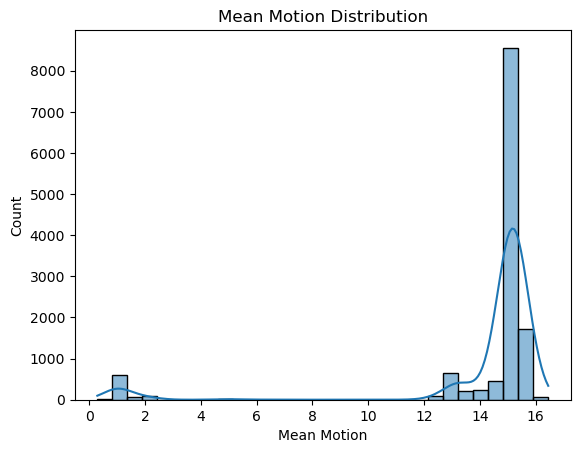

In [16]:
sns.histplot(data=df, x = 'MEAN_MOTION', bins = 30, kde=True)

plt.title('Mean Motion Distribution')
plt.xlabel('Mean Motion')


In [17]:
df['BSTAR'].value_counts()

BSTAR
0.000000    792
0.000240      7
0.000477      4
0.001387      3
0.000117      3
           ... 
0.000581      1
0.000585      1
0.000527      1
0.000521      1
0.000588      1
Name: count, Length: 11654, dtype: int64

(-0.2, 0.2)

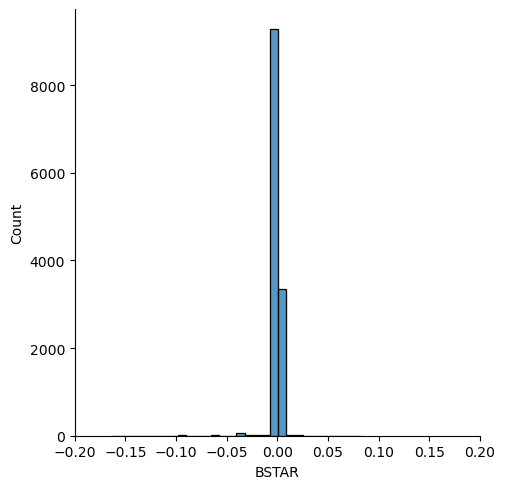

In [18]:
sns.displot(data=df, x = 'BSTAR', bins = 30)

plt.xlim(-0.2, 0.2)
#plt.ylim(-0.1, 2)

Text(0.5, 0, 'Revolutions')

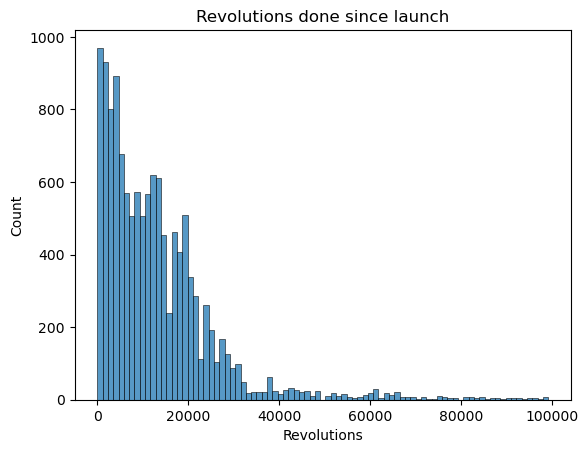

In [19]:
sns.histplot(data=df, x = 'REV_AT_EPOCH')

plt.title('Revolutions done since launch')
plt.xlabel('Revolutions')

In [20]:
# Compare total orbits done and the launch year distribution
launch_years = df['OBJECT_ID'].str.strip().str.split('-').str[0]

In [21]:
launch_years

0        1964
1        1964
2        1965
3        1965
4        1965
         ... 
12791    2025
12792    2025
12793    2025
12794    2025
12795    2025
Name: OBJECT_ID, Length: 12796, dtype: object

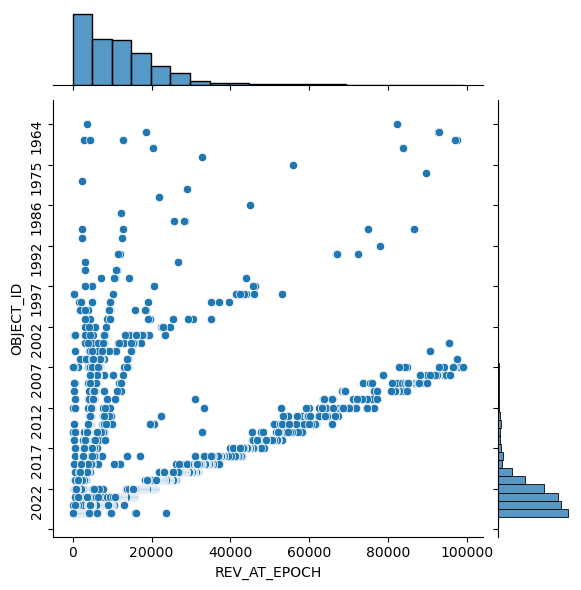

In [22]:
import matplotlib.ticker as ticker
g = sns.jointplot(data=df, x='REV_AT_EPOCH', y=launch_years, kind='scatter', marginal_kws=dict(bins=20, orientation="vertical"))

# Set a major tick for every 5 years on the y-axis
g.ax_joint.yaxis.set_major_locator(ticker.MultipleLocator(5))
g.ax_joint.tick_params(axis='y', rotation=90)

plt.show()